In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

In [34]:
def scalar2d_sd2_frames(J, K, N, P):
    """
    Generates snapshots of solution of 2D Tadmor-Tao model.

    Parameters
    ----------
    J : int
        Number of grid cells in x-direction per processor
    K : int
        Total number of grid cells in y-direction
    N : int
        Total number of outputs generated by CentPack
    P : int
        Number of processors used in the simulation
    """
    os.chdir('/Users/evandaniels/Research/CentPackL/simulation_scalar2d_SD2')
    os.makedirs('u_frames', exist_ok=True)

    y = np.loadtxt('mesh_files/y')

    x = np.empty((0,))
    for p in range(P):
        x_file = f'mesh_files/x_p{p:03d}'
        xp = np.loadtxt(x_file)
        x = np.concatenate([x, xp])

    u_min, u_max = np.inf, -np.inf
    for n in range(N + 1):
        for p in range(P):
            up = np.loadtxt(f'u_files/u_p{p:03d}_{n:03d}')
            u_min = min(u_min, up.min())
            u_max = max(u_max, up.max())

    levels = np.linspace(u_min, u_max, 20)

    for n in range(N + 1):
        u = np.empty((0, K))
        for p in range(P):
            u_file = f'u_files/u_p{p:03d}_{n:03d}'
            up = np.loadtxt(u_file)
            u = np.vstack([u, up])

        fig, ax = plt.subplots()
        # ax.contour(x, y, u.T, levels=20)
        # ax.set_xlim(0.0, 2.0 * np.pi)
        # ax.set_ylim(0.0, 2.0 * np.pi)
        
        cs = ax.contourf(x, y, u.T, levels=levels)
        ax.set_xlim(0.0, 2.0 * np.pi)
        ax.set_ylim(0.0, 2.0 * np.pi)

        ax.set_title('Tador Tao Semi-Discrete Solution')   # shows simulation time
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        fig.colorbar(cs, ax=ax, label='Velocity')

        u_frame = f'u_frames/u_{n:03d}.png'
        fig.savefig(u_frame, dpi='figure')
        plt.close(fig)
        # print(f'Saved frame {n}/{N}: {u_frame}')

In [35]:
scalar2d_sd2_frames(36, 144, 61, 8)

In [36]:
from PIL import Image
import glob

frames = [Image.open(f) for f in sorted(glob.glob('u_frames/*.png'))]
frames[0].save('scalar2d_SD2.gif', save_all=True, append_images=frames[1:], duration=100, loop=0)

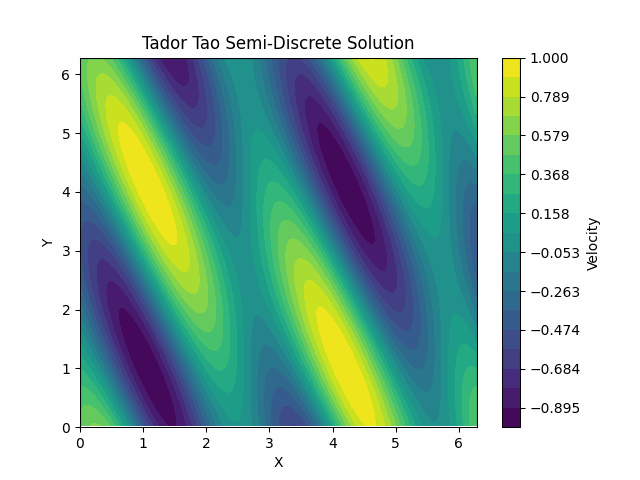

In [37]:
from IPython.display import Image as IPImage
IPImage('scalar2d_SD2.gif')